functions:
1. find the UP/DOWN bets for given assets over time (define: assets, time period) &rarr; DONE
2. collect YES/NO tokens &rarr; DONE
3. use graphql query to get orders for both tokens for all bets on all assets (order-level dataset (OLD)) &rarr; DONE
4. estimate statistics on OLD (std, high-low, mean etc) over time (define: time window)

links:
1. https://docs.polymarket.com/market-data/subgraph
2. https://api.goldsky.com/api/public/project_cl6mb8i9h0003e201j6li0diw/subgraphs/orderbook-subgraph/0.0.1/gn


In [ ]:
import requests, json, time, pandas as pd, pytz, yfinance as yf, numpy as np
from datetime import datetime as dt, timedelta, timezone, date
from concurrent.futures import ThreadPoolExecutor

class Orderbook:
    def __init__(self, days_back=7, max_workers=10, start_day_from_now=0, intraday_minutes=15):
        self.days_back = days_back
        self.start_day_from_now = start_day_from_now
        self.intraday_minutes = intraday_minutes
        self.max_workers = max_workers
        self.gamma_api = "https://gamma-api.polymarket.com/events/slug"
        self.goldsky_url = "https://api.goldsky.com/api/public/project_cl6mb8i9h0003e201j6li0diw/subgraphs/orderbook-subgraph/0.0.1/gn"
        self.timezone_map = {
            'new york': 'America/New_York',
            'london': 'Europe/London',
            'tokyo': 'Asia/Tokyo',
            'europe': 'Europe/Berlin'}
        self.asset_keys = []
        self.df = pd.DataFrame()
        self.orderbook = pd.DataFrame()

    def get_data(self, keys):
        self._get_multiple_tokens(keys)
        self._process_all_orderfills()

        def get_outcome_date(row): #to get the right match
            base_date = row['TIMESTAMP'].astimezone(pytz.timezone(self.timezone_map.get(row['country'].lower(), 'UTC'))).date()
            return base_date + timedelta(days=1) if 0 <= row['REL_HOUR'] < 8 else base_date

        self.orderbook['market_date'] = self.orderbook.apply(get_outcome_date, axis=1)
        stock_df = self._pull_stock_close()
        self.orderbook = self.orderbook.merge(
            stock_df,
            left_on=['KEY', 'market_date'],
            right_on=['KEY', 'date'], how='left')
        self.orderbook['TIMESTAMP'] = pd.to_datetime(self.orderbook['TIMESTAMP'])
        self.orderbook = self.orderbook.sort_values('TIMESTAMP')
        time_window_stock_pull = self.intraday_minutes #add 30 min too for robustness
        stock_min = self._pull_stock_minutes(minutes=time_window_stock_pull, window_size=120//time_window_stock_pull) #the window size determines std for BS: use past 120mins
        stock_min['TIMESTAMP'] = pd.to_datetime(stock_min['TIMESTAMP'])
        stock_min = stock_min.sort_values('TIMESTAMP')
        self.orderbook = pd.merge_asof(
            self.orderbook,
            stock_min,
            on='TIMESTAMP',
            by='KEY',
            direction='backward',
            tolerance=pd.Timedelta(f'{str(time_window_stock_pull)}min'))
        self.orderbook = self.orderbook.drop(columns=['date', 'market_date']).reset_index(drop=True)
        self.orderbook = self.orderbook.sort_values(by=['KEY', 'TIMESTAMP'], ascending=[True, True])
        return self.orderbook

    def _get_market_tokens(self, key_tuple):
        key = key_tuple[0]; country = key_tuple[1].lower()
        local_timezone = pytz.timezone(self.timezone_map.get(country, 'UTC'))
        now_local = dt.now(local_timezone) - timedelta(days=self.start_day_from_now)
        data = []
        for i in range(self.days_back):
            target = now_local - timedelta(days=i)
            slug = f"{key}-up-or-down-on-{target.strftime('%B-%-d-%Y').lower()}"
            try:
                r = requests.get(f"{self.gamma_api}/{slug}")
                if r.status_code == 200:
                    res_json = r.json()
                    if res_json.get("markets"):
                        m = res_json["markets"][0]
                        condition_id = m.get('conditionId')
                        tks = json.loads(m.get('clobTokenIds', '[]'))
                        data.append([key.upper(), target.date(), tks[0], tks[1], condition_id, country])
            except Exception as e:
                print(f"error fetching {slug}: {e}")
        #print(condition_id, tks[0], tks[1], target) #to get token - date to manually test on graphiQL
        return pd.DataFrame(data, columns=['key', 'ts', 'up_token', 'down_token', 'condition_id', 'country'])

    def _get_multiple_tokens(self, keys):
        all_dfs = []
        for k in keys:
            asset_name = k[0] if isinstance(k, tuple) else k
            self.asset_keys.append(asset_name.upper())
            print(f"--- collecting & processing: {asset_name.upper()} ---")
            raw = self._get_market_tokens(k if isinstance(k, tuple) else (k, 'new york'))
            all_dfs.append(raw)

        if not all_dfs: return pd.DataFrame()
        self.df = pd.concat(all_dfs).sort_values(['ts', 'key']).reset_index(drop=True)
        return self.df

    def _get_single_orderfills(self, a, start_dt, end_dt, up_down_key):
        q = '''query($a: String!, $g: BigInt!, $l: BigInt!) {
            orderFilledEvents(
              where: {
                or: [
                  {
                    timestamp_gte: $g,
                    timestamp_lte: $l,
                    takerAssetId: $a,
                    makerAssetId: "0"
                  },
                  {
                    timestamp_gte: $g,
                    timestamp_lte: $l,
                    makerAssetId: $a,
                    takerAssetId: "0"
                  }
                ]
              }
              orderBy: timestamp
              orderDirection: desc
            ) {
              id
              timestamp
              maker
              taker
              takerAssetId
              makerAssetId
              makerAmountFilled
              takerAmountFilled
            }
        }'''
        ts_g = int(start_dt.timestamp())
        ts_l = int(end_dt.timestamp())
        try:
            r = requests.post(self.goldsky_url, json={'query': q, 'variables': {'a': a, 'g': str(ts_g), 'l': str(ts_l)}}, timeout=15)
            if r.status_code != 200 or 'data' not in r.json(): return pd.DataFrame()
            events = r.json()['data']['orderFilledEvents']
            if not events: return pd.DataFrame()
            data = []
            for e in events:
                buy_shares = 'BUY' if str(e['takerAssetId']) == "0" else "SELL"
                m, t = int(e['makerAmountFilled'])/1e6, int(e['takerAmountFilled'])/1e6
                price = (t/m if e['takerAssetId'] == '0' else m/t) if m != 0 else 0
                price_up = round(price, 4) if up_down_key == 'UP' else round(1 - price, 4)
                data.append({
                    'UP_DOWN': up_down_key,
                    'TIMESTAMP': dt.fromtimestamp(int(e['timestamp']), tz=timezone.utc),
                    'MAKER': e['maker'],
                    'TAKER': e['taker'],
                    'SHARES': round(m, 4),
                    'USDC': round(t, 4),
                    'PRICE': round(price, 4),
                    'PRICE_UP': price_up,
                    'BUY_SELL': buy_shares,
                    'id': e['id'],
                    'log_odds': round(np.log(price/(1-price)), 4)})
            return pd.DataFrame(data)
        except Exception:
            return pd.DataFrame()

    def _process_all_orderfills(self):
        tasks = []
        now_utc = dt.now(timezone.utc) - timedelta(days=self.start_day_from_now)

        for _, row in self.df.iterrows():
            tz_name = self.timezone_map.get(row['country'], 'UTC')
            local_tz = pytz.timezone(tz_name)
            target_midnight = local_tz.localize(dt.combine(row['ts'], dt.min.time()))
            prev_close_local = target_midnight - timedelta(hours=8)
            market_start_utc = prev_close_local.astimezone(pytz.UTC)
            hour_step = 0.2 #12min to avoid hitting the 1k limit in orders per api call
            for side in ['up_token', 'down_token']:
                h = 0.0
                while h < 24:
                    chunk_start = market_start_utc + timedelta(hours=h)
                    if chunk_start >= now_utc: break
                    chunk_end = chunk_start + timedelta(hours=hour_step)
                    tasks.append({
                        'a': row[side], 's_dt': chunk_start, 'e_dt': chunk_end,
                        'side': 'UP' if 'up' in side else 'DOWN',
                        'key': row['key'],
                        'country': row['country']})
                    h += hour_step

        def fetch(t):
            res = self._get_single_orderfills(t['a'], t['s_dt'], t['e_dt'], t['side'])
            time.sleep(0.1) #for api call limit too, makes it veery long, but at least ensures we get all data
            if not res.empty:
                res['KEY'] = t['key']
                res['country'] = t['country']
            return res

        with ThreadPoolExecutor(max_workers=self.max_workers) as executor:
            results = list(executor.map(fetch, tasks))

        if not results: return pd.DataFrame()
        results = [r for r in results if not r.empty]
        expected_cols = ['KEY', 'UP_DOWN', 'TIMESTAMP', 'MAKER', 'TAKER', 'SHARES', 'USDC', 'PRICE', 'PRICE_UP','BUY_SELL','id']
        if not results:
            return pd.DataFrame(columns=expected_cols)
        df = pd.concat(results, ignore_index=True)
        if 'id' in df.columns:
            df.drop_duplicates(subset=['id'], keep='first', inplace=True)

        #here you get relative hours wrt the countries' markets, not UTC
        def get_relative_hr(row):
            tz = pytz.timezone(self.timezone_map.get(row['country'].lower(), 'UTC'))
            lt = tz.normalize(row['TIMESTAMP'].astimezone(tz))
            return (lt.hour + lt.minute/60 + lt.second/3600 + 8) % 24

        df['REL_HOUR'] = df.apply(get_relative_hr, axis=1)
        df['TIME_TO_EXP'] = (24.0 - df['REL_HOUR']).clip(lower=0)
        self.orderbook = df.sort_values(by=['KEY', 'TIMESTAMP'], ascending=[True, False]).reset_index(drop=True)
        cols = ['KEY', 'REL_HOUR', 'TIME_TO_EXP'] + [c for c in self.orderbook.columns if c not in ['id', 'KEY', 'REL_HOUR', 'TIME_TO_EXP']]
        self.orderbook = self.orderbook[cols]

        return self.orderbook

    def _pull_stock_close(self):
        tickers = self.orderbook['KEY'].unique().tolist()
        start, end = self.orderbook['TIMESTAMP'].min(), self.orderbook['TIMESTAMP'].max()
        df = yf.download(tickers, start=start.date(), end=(end + timedelta(days=1)).date(), progress=False, auto_adjust=True)
        df = df[['Open', 'Close']].stack(future_stack=True).reset_index()

        df.columns = ['date', 'KEY', 'close', 'open']
        df['date'] = df['date'].dt.date
        valid_days = self.orderbook.assign(date=self.orderbook['TIMESTAMP'].dt.date)[['KEY', 'date']].drop_duplicates()
        conds = [df['close'] > df['open'], df['close'] < df['open']]
        df['stock_up'] = np.select(conds, [1, 0], default=0.5)
        df = df.rename(columns={'close':'stock_close_day', 'open':'stock_open_day'})

        return df.merge(valid_days, on=['KEY', 'date'])[['KEY', 'date', 'stock_open_day', 'stock_close_day']]

    def _pull_stock_minutes(self, minutes=5, window_size=5):
        keys = self.orderbook['KEY'].unique().tolist()
        start = self.orderbook['TIMESTAMP'].min()
        end = self.orderbook['TIMESTAMP'].max()
        cutoff = dt.now(pytz.UTC) - timedelta(days=59)
        fetch_start = max(start, cutoff)

        if fetch_start >= end: return pd.DataFrame()
        df = yf.download(keys, start=fetch_start.date(), end=(end + timedelta(days=1)).date(),
                         interval=f"{minutes}m", progress=False, auto_adjust=True)
        suffix = f"_{minutes}m"
        if isinstance(df.columns, pd.MultiIndex):
            df = df[['High', 'Low', 'Close', 'Open', 'Volume']].stack(level=1, future_stack=True).reset_index()
            df.columns = ['TIMESTAMP', 'KEY', f'stock_close{suffix}', f'stock_high{suffix}', f'stock_low{suffix}', f'stock_open{suffix}', f'stock_volume{suffix}']
        else:
            df = df[['High', 'Low', 'Close', 'Open', 'Volume']].reset_index()
            df['KEY'] = keys[0]
            df.columns = ['TIMESTAMP', f'stock_close{suffix}', f'stock_high{suffix}', f'stock_low{suffix}', f'stock_open{suffix}', f'stock_volume{suffix}', 'KEY']

        #avg stock price from high-low and close price
        df[f'stock_avg{suffix}'] = (df[f'stock_high{suffix}'] + df[f'stock_low{suffix}'] + df[f'stock_close{suffix}']) / 3
        if df['TIMESTAMP'].dt.tz is None:
            df['TIMESTAMP'] = df['TIMESTAMP'].dt.tz_localize('UTC')
        else:
            df['TIMESTAMP'] = df['TIMESTAMP'].dt.tz_convert('UTC')
        df = df.sort_values(['KEY', 'TIMESTAMP'])
        df['returns'] = df.groupby('KEY')[f'stock_close{suffix}'].transform(lambda x: np.log(x / x.shift(1)))
        ann_factor = np.sqrt((60/minutes * 6.5) * 252)
        df[f'stock_vol{suffix}'] = df.groupby('KEY')['returns'].transform(
            lambda x: x.rolling(window=window_size).std() * ann_factor)
        return df.sort_values('TIMESTAMP')

In [ ]:
#this is the demo pt1
stocks = [('nflx', 'new york'), ('tsla', 'new york'), ('aapl', 'new york'), ('nvda', 'new york'), ('googl', 'new york'), ('meta', 'new york'), ('msft', 'new york'), ('amzn', 'new york')]
#indices = [('spx', 'new york'), ('nik', 'tokyo'), ('rut', 'london'), ('djia', 'new york'), ('ndx', 'new york'), ('dax', 'europe'), ('ukx', 'london')]
#commodities = [('cl', 'new york'), ('gc', 'new york'), ('si', 'new york')]
#assets = stocks + indices + commodities

intraday_window = 5 #or 30

orderbook_data = Orderbook(days_back=60, start_day_from_now=0, intraday_minutes=intraday_window).get_data(stocks)
orderbook_data

--- collecting & processing: NFLX ---
--- collecting & processing: TSLA ---
--- collecting & processing: AAPL ---
--- collecting & processing: NVDA ---
--- collecting & processing: GOOGL ---
--- collecting & processing: META ---
--- collecting & processing: MSFT ---
--- collecting & processing: AMZN ---


,KEY,REL_HOUR,TIME_TO_EXP,UP_DOWN,TIMESTAMP,MAKER,TAKER,SHARES,USDC,PRICE,...,stock_open_day,stock_close_day,stock_close_5m,stock_high_5m,stock_low_5m,stock_open_5m,stock_volume_5m,stock_avg_5m,returns,stock_vol_5m
10,AAPL,0.882222,23.117778,DOWN,2026-02-02 21:52:56+00:00,0x50893670841372c06a625d9f24fa303afc519754,0x95ec5157e205fc39aa5cfc78a6c4d2155515501d,8.1818,18.1818,0.450,...,269.228088,268.948351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,AAPL,0.882222,23.117778,UP,2026-02-02 21:52:56+00:00,0x95ec5157e205fc39aa5cfc78a6c4d2155515501d,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,10.0000,18.1818,0.550,...,269.228088,268.948351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,AAPL,1.874444,22.125556,UP,2026-02-02 22:52:28+00:00,0xc3cff162bf358d805157d23ea13c8e485c4a1e59,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,1.0000,1.8182,0.550,...,269.228088,268.948351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,AAPL,1.874444,22.125556,DOWN,2026-02-02 22:52:28+00:00,0x50893670841372c06a625d9f24fa303afc519754,0xc3cff162bf358d805157d23ea13c8e485c4a1e59,0.8182,1.8182,0.450,...,269.228088,268.948351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45,AAPL,5.481111,18.518889,DOWN,2026-02-03 02:28:52+00:00,0x50893670841372c06a625d9f24fa303afc519754,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,19.9900,10.9945,0.550,...,269.228088,268.948351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113355,TSLA,22.235833,1.764167,UP,2026-04-02 18:14:09+00:00,0x3329cfc2b8d8ceb8d198f081bdf4262f421f43a6,0x8245ea0d5a476678cb354b69e136908f0757ebed,0.5000,500.0000,0.001,...,360.589996,364.200012,360.480011,359.850006,360.343201,359.940002,591622.0,360.224406,-0.000333,0.217801
113419,TSLA,22.682500,1.317500,DOWN,2026-04-02 18:40:57+00:00,0xad7888efb18d7cec07b14598ab9500c0ef51678c,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,7.9900,7.9820,0.999,...,360.589996,364.200012,360.950012,360.320007,360.720001,360.399994,861837.0,360.663340,0.000887,0.208461
113420,TSLA,22.682500,1.317500,DOWN,2026-04-02 18:40:57+00:00,0x8245ea0d5a476678cb354b69e136908f0757ebed,0xad7888efb18d7cec07b14598ab9500c0ef51678c,7.9820,7.9900,0.999,...,360.589996,364.200012,360.950012,360.320007,360.720001,360.399994,861837.0,360.663340,0.000887,0.208461
113443,TSLA,22.937500,1.062500,DOWN,2026-04-02 18:56:15+00:00,0x8245ea0d5a476678cb354b69e136908f0757ebed,0x88936a9b5758388749be0ac49680bca510f990e6,999.0000,1000.0000,0.999,...,360.589996,364.200012,360.049896,359.600006,359.939911,360.029999,578915.0,359.863271,-0.001582,0.198997


In [ ]:
#you save the orderbooks, so that you can extend the sample period from just 60 days (due to yahoo availability) to 60+x, where x is the days in a row you run the code; then merge all resulting df
import google.auth
from google.colab import auth
import gspread
from gspread_dataframe import set_with_dataframe
from datetime import date

# 1. Auth and Initialize
auth.authenticate_user()

# 2. Now 'google' is defined and can be used
creds, _ = google.auth.default()
gc = gspread.authorize(creds)

# Create the Sheet
title = f"orderbook_{intraday_window}min_{date.today()}"
sheet = gc.create(title)

# Upload data (stripping timezones for compatibility)
set_with_dataframe(sheet.get_worksheet(0), orderbook_data.apply(lambda x: x.dt.tz_localize(None) if hasattr(x, 'dt') else x))

print(f"Done! View your data here: https://docs.google.com/spreadsheets/d/{sheet.id}")

Done! View your data here: https://docs.google.com/spreadsheets/d/1YtB82jwHwvPuH7lFh87A6iFT3beuKdLjHSNFIbwS_Kw


In [ ]:
clean_orderbook = orderbook_data.dropna().reset_index(drop=True); exchange = clean_orderbook['TAKER'].value_counts().index[0]
clean_orderbook = clean_orderbook[clean_orderbook['TAKER']!=exchange].reset_index(drop=True)
print(clean_orderbook.columns)
print(clean_orderbook.shape)
clean_orderbook

Index(['KEY', 'REL_HOUR', 'TIME_TO_EXP', 'UP_DOWN', 'TIMESTAMP', 'MAKER',
       'TAKER', 'SHARES', 'USDC', 'PRICE', 'PRICE_UP', 'BUY_SELL', 'log_odds',
       'country', 'stock_open_day', 'stock_close_day', 'stock_close_5m',
       'stock_high_5m', 'stock_low_5m', 'stock_open_5m', 'stock_volume_5m',
       'stock_avg_5m', 'returns', 'stock_vol_5m'],
      dtype='object')
(53916, 24)


,KEY,REL_HOUR,TIME_TO_EXP,UP_DOWN,TIMESTAMP,MAKER,TAKER,SHARES,USDC,PRICE,...,stock_open_day,stock_close_day,stock_close_5m,stock_high_5m,stock_low_5m,stock_open_5m,stock_volume_5m,stock_avg_5m,returns,stock_vol_5m
0,AAPL,19.516667,4.483333,DOWN,2026-02-03 16:31:00+00:00,0x4254354429e2ac0123744bfa81f2dbee2b6e1182,0x969fae0a3a93778adc42178f72c612ed8c4e4d55,10.000,6.60,0.660,...,269.228088,268.948351,269.609985,268.549988,269.549988,268.899994,291924.0,269.236654,0.000482,0.374184
1,AAPL,19.570556,4.429444,UP,2026-02-03 16:34:14+00:00,0x5fe50c22621779e031322c5becb110d1fa0d8b99,0x969fae0a3a93778adc42178f72c612ed8c4e4d55,10.000,3.00,0.300,...,269.228088,268.948351,269.609985,268.549988,269.549988,268.899994,291924.0,269.236654,0.000482,0.374184
2,AAPL,19.666667,4.333333,DOWN,2026-02-03 16:40:00+00:00,0xb7fa0d0a47dab8e381f13997f0240c9763cd89e2,0x2910eda74b54235302360007be2832dea91dec9c,52.000,100.00,0.520,...,269.228088,268.948351,270.500000,269.720093,269.734985,270.209991,750436.0,269.985026,0.000925,0.367842
3,AAPL,19.666667,4.333333,DOWN,2026-02-03 16:40:00+00:00,0x969fae0a3a93778adc42178f72c612ed8c4e4d55,0x2910eda74b54235302360007be2832dea91dec9c,122.200,260.00,0.470,...,269.228088,268.948351,270.500000,269.720093,269.734985,270.209991,750436.0,269.985026,0.000925,0.367842
4,AAPL,19.752778,4.247222,DOWN,2026-02-03 16:45:10+00:00,0x2910eda74b54235302360007be2832dea91dec9c,0xca531aa496adedafba8b6c953bd959d4a7ff17fd,2.800,5.00,0.560,...,269.228088,268.948351,269.980011,269.595001,269.649994,269.760010,232872.0,269.741669,-0.001924,0.363500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53911,TSLA,22.235833,1.764167,UP,2026-04-02 18:14:09+00:00,0xeab7b0a830a1755f1296fee950b3080e3529b389,0x8245ea0d5a476678cb354b69e136908f0757ebed,0.050,50.00,0.001,...,360.589996,364.200012,360.480011,359.850006,360.343201,359.940002,591622.0,360.224406,-0.000333,0.217801
53912,TSLA,22.235833,1.764167,UP,2026-04-02 18:14:09+00:00,0x28fe91fb61ddaaef565d0e8bac44b95bc0373d29,0x8245ea0d5a476678cb354b69e136908f0757ebed,0.200,200.00,0.001,...,360.589996,364.200012,360.480011,359.850006,360.343201,359.940002,591622.0,360.224406,-0.000333,0.217801
53913,TSLA,22.235833,1.764167,UP,2026-04-02 18:14:09+00:00,0x3329cfc2b8d8ceb8d198f081bdf4262f421f43a6,0x8245ea0d5a476678cb354b69e136908f0757ebed,0.500,500.00,0.001,...,360.589996,364.200012,360.480011,359.850006,360.343201,359.940002,591622.0,360.224406,-0.000333,0.217801
53914,TSLA,22.682500,1.317500,DOWN,2026-04-02 18:40:57+00:00,0x8245ea0d5a476678cb354b69e136908f0757ebed,0xad7888efb18d7cec07b14598ab9500c0ef51678c,7.982,7.99,0.999,...,360.589996,364.200012,360.950012,360.320007,360.720001,360.399994,861837.0,360.663340,0.000887,0.208461


In [ ]:
from scipy.stats import norm
def collapse_to_windows(df, minutes=5, risk_free_ann=0.04):
    window = f'{str(minutes)}Min'
    df['vol_bull'] = np.where(
        ((df['BUY_SELL'] == 'BUY') & (df['UP_DOWN'] == 'UP')) |
        ((df['BUY_SELL'] == 'SELL') & (df['UP_DOWN'] == 'DOWN')),
        df['USDC'], 0)

    df['vol_bear'] = np.where(
        ((df['BUY_SELL'] == 'SELL') & (df['UP_DOWN'] == 'UP')) |
        ((df['BUY_SELL'] == 'BUY') & (df['UP_DOWN'] == 'DOWN')),
        df['USDC'], 0)

    df = df.set_index('TIMESTAMP')
    suffix = f"_{minutes}m"
    agg_dict = {
        'TIME_TO_EXP': 'last',
        'PRICE_UP': ['first', 'last', 'mean', 'max', 'min'],
        'USDC': 'sum',
        'SHARES': 'count',
        'vol_bull': 'sum',
        'vol_bear': 'sum',
        'stock_open_day': 'last',
        f'stock_close{suffix}': 'last',
        f'stock_avg{suffix}': 'mean',
        f'stock_vol{suffix}': 'last'}

    collapsed = df.groupby('KEY').resample(window).agg(agg_dict)
    collapsed.columns = ['time_to_exp',
        'open_bet', 'close_bet', 'avg_price_up', 'high_bet', 'low_bet',
        'total_volume', 'trade_count', 'bull_volume', 'bear_volume',
        'stock_open_day', 'stock_close', 'stock_avg_period', 'stock_vol']

    collapsed['poly_vol_imbalance'] = (collapsed['bull_volume']/collapsed['bear_volume'])-1
    collapsed['poly_vol_imbalance'] = np.where(collapsed['poly_vol_imbalance'].isna(), 1, collapsed['poly_vol_imbalance'])
    collapsed.drop(columns=['bull_volume', 'bear_volume'], inplace=True)
    # compute theoretical value with BS cash-or-nothing neutral probability for call opt (N(d2), so it's a prob)
    S = collapsed['stock_close'] #the current price is the price of the stock when the window ends
    K = collapsed['stock_open_day']
    sigma = collapsed['stock_vol']
    T = ((collapsed['time_to_exp'] / 24) / 252).clip(lower=1e-9) # time to exp in years

    # d2 formula for neutral probability
    d2 = (np.log(S / K) + (risk_free_ann - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T).replace(0, np.nan))
    collapsed['bs_neutral_prob'] = norm.cdf(d2.fillna(0))
    collapsed['true_sentiment'] = collapsed['avg_price_up'] - collapsed['bs_neutral_prob'] #difference between polymarket prices and fair price: the signal!
    return collapsed.dropna().reset_index()

df_15m = collapse_to_windows(orderbook_data, minutes=intraday_window) #this is a cool df

In [ ]:
df_15m

,KEY,TIMESTAMP,time_to_exp,open_bet,close_bet,avg_price_up,high_bet,low_bet,total_volume,trade_count,stock_open_day,stock_close,stock_avg_period,stock_vol,poly_vol_imbalance,bs_neutral_prob,true_sentiment
0,AAPL,2026-02-03 16:30:00+00:00,4.429444,0.340,0.300,0.320,0.340,0.300,29.600,4,269.228088,269.609985,269.236654,0.374184,-0.216867,0.554804,-0.234804
1,AAPL,2026-02-03 16:40:00+00:00,4.333333,0.480,0.530,0.505,0.530,0.480,534.200,4,269.228088,270.500000,269.985026,0.367842,1.066590,0.683201,-0.178201
2,AAPL,2026-02-03 16:45:00+00:00,4.247222,0.440,0.440,0.440,0.440,0.440,10.000,2,269.228088,269.980011,269.741669,0.363500,0.000000,0.613186,-0.173186
3,AAPL,2026-02-03 16:50:00+00:00,4.163333,0.360,0.360,0.360,0.360,0.360,720.000,2,269.228088,269.630005,269.123332,0.343573,0.000000,0.565147,-0.205147
4,AAPL,2026-02-03 16:55:00+00:00,4.054444,0.250,0.250,0.250,0.250,0.250,6.250,2,269.228088,269.000000,268.913432,0.340630,-0.750000,0.461177,-0.211177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12432,TSLA,2026-04-02 17:10:00+00:00,2.773056,0.020,0.020,0.020,0.020,0.020,8.700,2,360.589996,365.579987,365.203328,0.195280,0.000000,0.999497,-0.979497
12433,TSLA,2026-04-02 17:15:00+00:00,2.736389,0.010,0.010,0.010,0.010,0.010,270.000,6,360.589996,366.059998,365.733358,0.199894,0.000000,0.999802,-0.989802
12434,TSLA,2026-04-02 18:10:00+00:00,1.764167,0.001,0.001,0.001,0.001,0.001,1500.000,4,360.589996,360.480011,360.224406,0.217801,0.000000,0.467827,-0.466827
12435,TSLA,2026-04-02 18:40:00+00:00,1.317500,0.001,0.001,0.001,0.001,0.001,15.972,2,360.589996,360.950012,360.663340,0.208461,0.001002,0.627648,-0.626648


In [ ]:
def check_lead_lag(df): #add lagged daily volume on polymarket to account to liquidity of the bet in general
    df = df.sort_values(['KEY', 'TIMESTAMP'])
    df['next_stock_move'] = np.log(df.groupby('KEY')['stock_close'].shift(-1) / df['stock_close']) #percentage change
    df['curr_stock_move'] = np.log(df['stock_close'] / df.groupby('KEY')['stock_close'].shift(1))
    df['next_true_sent'] = df.groupby('KEY')['true_sentiment'].shift(-1) - df['true_sentiment'] #here simple diff because the value can be negative
    df['abs_sentiment'] =df['true_sentiment'].abs() #abs sentiment is a measure of 'conviction' that price is going to go up/down, if ~ 0, then not very convincing
    valid = df[df['time_to_exp'] > 0.5].dropna()
    overall_lead = valid['true_sentiment'].corr(valid['next_stock_move'])
    asset_lead = valid.groupby('KEY').apply(lambda x: x['true_sentiment'].corr(x['next_stock_move']), include_groups=False)
    overall_lag = valid['curr_stock_move'].corr(valid['next_true_sent'])
    asset_lag = valid.groupby('KEY').apply(lambda x: x['curr_stock_move'].corr(x['next_true_sent']), include_groups=False)

    print(f"Overall lead correlation: {overall_lead:.4f}")
    print("Lead correlation by asset:")
    print(asset_lead, '\n')
    print("-"*30, '\n')
    print(f"Overall lag correlation: {overall_lag:.4f}")
    print("Lag correlation by asset:")
    print(asset_lag)
    return df

df_15m = check_lead_lag(df_15m)
df_15m

Overall lead correlation: 0.1688
Lead correlation by asset:
KEY
AAPL     0.209294
AMZN     0.144924
GOOGL    0.172816
META     0.177764
MSFT     0.176749
NFLX     0.182609
NVDA     0.178934
TSLA     0.160083
dtype: float64 

------------------------------ 

Overall lag correlation: 0.0362
Lag correlation by asset:
KEY
AAPL     0.034207
AMZN     0.017024
GOOGL    0.032890
META     0.042438
MSFT     0.071121
NFLX     0.052199
NVDA     0.000409
TSLA     0.043112
dtype: float64


,KEY,TIMESTAMP,time_to_exp,open_bet,close_bet,avg_price_up,high_bet,low_bet,total_volume,trade_count,...,stock_close,stock_avg_period,stock_vol,poly_vol_imbalance,bs_neutral_prob,true_sentiment,next_stock_move,curr_stock_move,next_true_sent,abs_sentiment
0,AAPL,2026-02-03 16:30:00+00:00,4.429444,0.340,0.300,0.320,0.340,0.300,29.600,4,...,269.609985,269.236654,0.374184,-0.216867,0.554804,-0.234804,0.003296,NaN,0.056603,0.234804
1,AAPL,2026-02-03 16:40:00+00:00,4.333333,0.480,0.530,0.505,0.530,0.480,534.200,4,...,270.500000,269.985026,0.367842,1.066590,0.683201,-0.178201,-0.001924,0.003296,0.005015,0.178201
2,AAPL,2026-02-03 16:45:00+00:00,4.247222,0.440,0.440,0.440,0.440,0.440,10.000,2,...,269.980011,269.741669,0.363500,0.000000,0.613186,-0.173186,-0.001297,-0.001924,-0.031961,0.173186
3,AAPL,2026-02-03 16:50:00+00:00,4.163333,0.360,0.360,0.360,0.360,0.360,720.000,2,...,269.630005,269.123332,0.343573,0.000000,0.565147,-0.205147,-0.002339,-0.001297,-0.006030,0.205147
4,AAPL,2026-02-03 16:55:00+00:00,4.054444,0.250,0.250,0.250,0.250,0.250,6.250,2,...,269.000000,268.913432,0.340630,-0.750000,0.461177,-0.211177,0.001296,-0.002339,0.120526,0.211177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12432,TSLA,2026-04-02 17:10:00+00:00,2.773056,0.020,0.020,0.020,0.020,0.020,8.700,2,...,365.579987,365.203328,0.195280,0.000000,0.999497,-0.979497,0.001312,0.002300,-0.010305,0.979497
12433,TSLA,2026-04-02 17:15:00+00:00,2.736389,0.010,0.010,0.010,0.010,0.010,270.000,6,...,366.059998,365.733358,0.199894,0.000000,0.999802,-0.989802,-0.015361,0.001312,0.522975,0.989802
12434,TSLA,2026-04-02 18:10:00+00:00,1.764167,0.001,0.001,0.001,0.001,0.001,1500.000,4,...,360.480011,360.224406,0.217801,0.000000,0.467827,-0.466827,0.001303,-0.015361,-0.159821,0.466827
12435,TSLA,2026-04-02 18:40:00+00:00,1.317500,0.001,0.001,0.001,0.001,0.001,15.972,2,...,360.950012,360.663340,0.208461,0.001002,0.627648,-0.626648,-0.002497,0.001303,0.342277,0.626648


In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error as mae, r2_score as r2

def analyse_sentiment_dynamics(df):
    cols = ['time_to_exp', 'true_sentiment', 'next_stock_move', 'abs_sentiment', 'curr_stock_move']
    df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=cols)
    upper_limit = df['abs_sentiment'].quantile(0.95) #ignore top 5% extreme noise tail
    df = df[df['abs_sentiment'] < upper_limit].copy()
    df['is_hit'] = (np.sign(df['true_sentiment']) == np.sign(df['next_stock_move'])).astype(int) #hit rate=polymarket predicts same price direction!
    df['avg_trade'] = df['total_volume']/df['trade_count']
    df = df.dropna()

    print(f"{'percentile':<15} | {"min abs 'conviction'":<15} | {'hit rate (%)':<12} | {'N'}")
    print("-" * 60)
    for p in [0.0, 0.5, 0.75, 0.90, 0.95]:
        thresh = df['abs_sentiment'].quantile(p)
        sub = df[df['abs_sentiment'] >= thresh]
        label = f"top {int((1-p)*100)}%" if p > 0 else "all signals"
        print(f"{label:<15} | {thresh:>20.4f} | {sub['is_hit'].mean()*100:>11.2f}% | {len(sub)}")

    X_var = ['true_sentiment', 'poly_vol_imbalance', 'avg_trade', 'stock_vol']#, 'curr_stock_move'] #they are from time t; y is from t+1
    for var_num in [len(X_var)+1]:#range(1, len(X_var)+1):
        print("\n"+"="*30 + "\nresults from polymarket sentiment on price change OLS:\n") #can do other models too, maybe GLS or logit
        results= []
        X_variable_loop = X_var[0:var_num]
        for asset, data in df.groupby('KEY'):
            data = data.dropna(subset=['next_stock_move'] + X_variable_loop)
            X = sm.add_constant(data[X_variable_loop])
            res = sm.OLS(data['next_stock_move'], X).fit(cov_type='HAC', cov_kwds={'maxlags': int(len(X)**(1/3))}) #rule of thumb in lutkephol (n)^(1/3)
            results.append({'Asset': asset, **res.params.to_dict(), **res.tvalues.add_suffix('_t-stat').to_dict(), 'R2%': res.rsquared*100, 'MAE': res.resid.abs().mean()})
        final_df = pd.DataFrame(results).set_index('Asset').drop(columns='const_t-stat')
        print(final_df)
        print('\ncoefficients*100 are pp increases in stock price following a 1 unit increase in polymarket conviction measure')

    #gpt - do better (cross-validate)
    #def add_ml_panel_results(df, X_var):
    #    df = df.sort_values('TIMESTAMP')
    #    unique_times = df['TIMESTAMP'].unique()
    #    cutoff_time = unique_times[int(len(unique_times) * 0.8)]

    #    train_df = df[df['TIMESTAMP'] < cutoff_time].copy()
    #    test_df = df[df['TIMESTAMP'] >= cutoff_time].copy()

    #    X_train, y_train = train_df[X_var].fillna(0), train_df['next_stock_move'].fillna(0)

        # Train both global models
    #    rf_g = RandomForestRegressor(n_estimators=100, max_depth=5).fit(X_train, y_train)
    #    xgb_g = XGBRegressor(n_estimators=100, max_depth=1).fit(X_train, y_train)

    #    panel_results = []
    #    for asset, data in test_df.groupby('KEY'):
    #        X_t, y_t = data[X_var].fillna(0), data['next_stock_move'].fillna(0)
    #        if len(y_t) < 5: continue

    #        panel_results.append({
    #            'Asset': asset,
    #            'RF_Test_R2': r2(y_t, rf_g.predict(X_t)),
    #            'XGB_Test_R2': r2(y_t, xgb_g.predict(X_t)),
    #            # Importances (Global)
    #            **{f'RF_Imp_{c}': v for c, v in zip(X_var, rf_g.feature_importances_)},
    #            **{f'XGB_Imp_{c}': v for c, v in zip(X_var, xgb_g.feature_importances_)}
    #        })

    #    return pd.DataFrame(panel_results).set_index('Asset')

    #final_ml_df = add_ml_panel_results(df, X_var)
    #print(final_ml_df)

    print("\n"+"="*30 + "\nlogit for direction (up signal --> up move):\n")
    logit_results = []
    df['sig_up'] = (df['true_sentiment'] > 0).astype(int)
    df['mov_up'] = (df['next_stock_move'] > 0).astype(int)

    for asset, data in df.groupby('KEY'):
        data = data.dropna(subset=['mov_up', 'sig_up'] + X_variable_loop)
        if len(data) < 20: continue
        X = sm.add_constant(data[['sig_up'] + X_var[1:]])
        try:
            res = sm.Logit(data['mov_up'], X).fit(disp=0)
            p_dn = 1 / (1 + np.exp(-res.params['const']))
            p_up = 1 / (1 + np.exp(-(res.params['const'] + res.params['sig_up'])))
            logit_results.append({
                    'asset': asset,
                    'z-Stat': res.tvalues['sig_up'],
                    'P(up|sig_down)%': p_dn * 100,
                    'P(up|sig_up)%': p_up * 100,
                    'P(up|sig_up) - P(up|sig_down)%': (p_up - p_dn) * 100,
                    'n': len(data)})
        except: continue
    print(pd.DataFrame(logit_results).set_index('asset'))

    print('\n'+'='*30)
    df['hour'] = pd.to_datetime(df['TIMESTAMP']).dt.hour #how predictive power changes during the trading day
    print("\nhit rate by hour:")
    print(df.groupby('hour')['is_hit'].mean())

analyse_sentiment_dynamics(df_15m)


percentile      | min abs 'conviction' | hit rate (%) | N
------------------------------------------------------------
all signals     |               0.0000 |       56.10% | 11798
top 50%         |               0.3244 |       58.81% | 5899
top 25%         |               0.6088 |       61.19% | 2950
top 9%          |               0.8175 |       64.15% | 1180
top 5%          |               0.8973 |       63.90% | 590

results from polymarket sentiment on price change OLS:

          const  true_sentiment  poly_vol_imbalance     avg_trade  stock_vol  \
Asset                                                                          
AAPL   0.000096        0.000828       -2.232024e-06 -1.519783e-07  -0.000239   
AMZN  -0.000123        0.000946       -9.751077e-07  1.117431e-06   0.000372   
GOOGL -0.000129        0.000803       -5.359515e-06  9.316220e-07   0.000738   
META   0.000189        0.001275       -8.285424e-07  1.934029e-06  -0.000975   
MSFT   0.000132        0.000793       -

In [ ]:
#when you buy at t, before selling at t+1, check whether signal is still above min_confidence and same sign: if so, hold --> reduce commission costs
#sharpe ratio

def pro_backtest(df, initial_capital=10000, leverage=1, min_confidence=0.8, max_bet_pct=0.05, pct_cost=0.01, min_cash=500,
                 asset=None, print_results=True, strategy='long-short', risk_free_ann=0.04):
    risk_free_daily = (1+risk_free_ann)**(1/252)-1
    df = df.dropna(subset=['next_stock_move', 'abs_sentiment', 'true_sentiment'])
    if asset: df = df[df['KEY'].isin(asset)]
    if strategy == 'long-only':
        df = df[df['true_sentiment']>0]
    elif strategy=='short-only':
        df = df[df['true_sentiment']<0]
    else:
        pass
    signals = df[(df['abs_sentiment'] >= min_confidence) & (df['abs_sentiment'] < 0.95)].copy()
    if len(signals) == 0: print("No signals found :/"); return
    signals = signals.set_index('TIMESTAMP').sort_index()
    current_cash = initial_capital
    peak = initial_capital
    mdd_tracker = 0
    results = []
    commission = pct_cost / 100

    for ts, group in signals.groupby(level=0):
        if current_cash <= min_cash: break
        num_trades = len(group) #to make sure you are not double spending for simultaneous trades
        total_window_bet = (current_cash * max_bet_pct * leverage)
        individual_bet = total_window_bet / num_trades

        for _, trade in group.iterrows():
            if current_cash - individual_bet < min_cash: continue
            position_size = individual_bet * trade['abs_sentiment']
            directional_move = np.sign(trade['true_sentiment']) * trade['next_stock_move']
            gross_pnl = position_size * directional_move
            total_fees = position_size * (2 * commission + 0.1*(leverage-1)/10000) #some kind of 'leverage tax' so that it is not feasible to use infinite leverage
            trade_ret_net = directional_move - (2 * commission)
            pnl = gross_pnl - total_fees
            current_cash += pnl

            if current_cash > peak: peak = current_cash
            dd = (peak - current_cash) / peak
            mdd_tracker = max(mdd_tracker, dd)
            results.append({
                'timestamp': ts,
                'KEY': trade['KEY'],
                'pnl': pnl,
                'ret': trade_ret_net,
                'equity': current_cash})

    res = pd.DataFrame(results)
    #print(res.head())
    res = res.set_index('timestamp')
    daily_pnl = res['pnl'].resample('D').sum().fillna(0) #fill days with no trades with 0% returns
    daily_equity = daily_pnl.cumsum() + initial_capital
    daily_pct_change = np.log(daily_equity / daily_equity.shift(1)).fillna(0) #to fill the first missing value with a 0% return
    mean_ret = daily_pct_change.mean()
    std_ret = daily_pct_change.std()
    sharpe = ((mean_ret - risk_free_daily)/ std_ret) * np.sqrt(252) if std_ret != 0 else 0
    total_ret = (current_cash - initial_capital) / initial_capital
    win_rate = (res['pnl'] > 0).mean()

    backtest_stats = {
        'trade count': len(res),
        'win rate': win_rate,
        'total return': total_ret,
        'initial value': initial_capital,
        'final value': current_cash,
        'max drawdown': mdd_tracker,
        'sharpe ratio': sharpe,
        'leverage': leverage
    }

    if print_results:
        print(f"=== pro backtest --> min conviction: {int(min_confidence*100)}% ===")
        print(f"trade count:   {len(res)}")
        print(f"win rate:      {win_rate:.2%}")
        print(f"total return:  {total_ret:.2%}")
        print(f"final value:   ${current_cash:,.2f}")
        print(f"max drawdown:  {mdd_tracker:.2%}")
        print(f"sharpe ratio:  {sharpe:.2f}", end=' '); print('(money money ^u^)') if sharpe > 0 else print()
        print(f"leverage:      x{leverage:.1f} | cost: {pct_cost} bps")
        print('daily risk free rate', round(risk_free_daily*100,4), '%')
        print('average return', round(mean_ret*100, 4),'%')
        print('st dev', round(std_ret*100,4),'%')
        print("\nreturn by asset (% of init cap):")
        print(res.groupby('KEY')['pnl'].sum() / initial_capital * 100)
    return res, backtest_stats

results_df = pro_backtest(df_15m, leverage=1, min_confidence=0.8, pct_cost=0.01, risk_free_ann=0.03, strategy='long-short')

=== pro backtest --> min conviction: 80% ===
trade count:   1165
win rate:      58.88%
total return:  2.63%
final value:   $10,263.21
max drawdown:  0.15%
sharpe ratio:  6.21 (money money ^u^)
leverage:      x1.0 | cost: 0.01 bps
daily risk free rate 0.0117 %
average return 0.0425 %
st dev 0.0787 %

return by asset (% of init cap):
KEY
AAPL     0.259922
AMZN     0.285818
GOOGL    0.020697
META     0.478076
MSFT     0.324358
NFLX     0.387276
NVDA     0.484329
TSLA     0.391663
Name: pnl, dtype: float64


In [ ]:
##==================== BUG!!! i am not correctly subtracting/adding cash before/during/after the investment =================

#fixes:
# 1) sharpe ratio (with riskfree)
# 2) earn riskfree on idle cash (done)
# 3) hold position across time windows if sentiment is still significant and same sign
# 4) cannot hold overnight, since the previous 15 min signal for the following day refers to the previous day

def pro_backtest(df, initial_capital=10000, leverage=1, min_confidence=0.8, max_bet_pct=0.1, pct_cost=0.01, min_cash=5000,
                 asset=None, print_results=True, strategy='long-short', risk_free_ann=0.04):
    risk_free_daily = (1+risk_free_ann)**(1/252)-1 #for sharp
    risk_free_min = (1 + risk_free_daily)**(1/(24*60)) - 1 #for interest on idle cash
    original_min_date = df['TIMESTAMP'].min()
    df = df[df['TIMESTAMP'] >= original_min_date + pd.Timedelta(days=1)] if original_min_date.hour > 13 else df #to make sure you start from the next whole trading day (UTC hr)
    df = df.dropna(subset=['next_stock_move', 'abs_sentiment', 'true_sentiment'])
    start_date = df['TIMESTAMP'].min()
    end_date = df['TIMESTAMP'].max()
    if asset: df = df[df['KEY'].isin(asset)]
    if strategy == 'long-only':
        df = df[df['true_sentiment']>0]
    elif strategy=='short-only':
        df = df[df['true_sentiment']<0]
    else:
        pass
    signals = df[(df['abs_sentiment'] >= min_confidence)]# & (df['abs_sentiment'] < 0.95)].copy()
    if len(signals) == 0: print("No signals found :/"); return
    signals = signals.set_index('TIMESTAMP').sort_index()
    current_cash = initial_capital
    total_idle_interest = 0
    peak = initial_capital
    mdd_tracker = 0
    results = []
    commission = pct_cost / 100

    last_ts = df['TIMESTAMP'].min()
    current_positions = {}

    all_days = pd.date_range(start=start_date.normalize() + pd.Timedelta(days=1),
                          end=end_date.normalize(),
                          freq='D')
    eod_times = pd.date_range( #this is to avoid overnight trading; a signal at 19:45 cannot determine a trx at 13 the next day
            start=start_date.normalize(),
            end=end_date.normalize() + pd.Timedelta(days=1),
            freq='D'
        ).map(lambda d: d.replace(hour=20, minute=0))  # 20:00 UTC = 16:00 ET

    all_timestamps = sorted(set(signals.index.tolist() + all_days.tolist() + eod_times.tolist()))

    for ts in all_timestamps:#signals.groupby(level=0):
        if current_cash <= min_cash: break
        minutes_passed = (ts - last_ts).total_seconds() / 60
        if minutes_passed > 0:
            pre_interest_cash = current_cash
            current_cash *= (1 + risk_free_min)**minutes_passed
            interest_gained = current_cash - pre_interest_cash
            total_idle_interest += interest_gained
            results.append({
                'timestamp': ts,
                'KEY': 'interest_on_cash',
                'pnl': interest_gained,
                'equity': current_cash
            })
        last_ts = ts
        if ts.hour == 20 and ts.minute == 0: #force exit at market close
            for asset, pos in list(current_positions.items()):
                current_cash -= (pos['size'] * commission)
            current_positions.clear()
            continue
        if ts not in signals.index: continue
        if ts.hour >= 20: continue #ignore signals from last time window of the day
        group = signals.loc[ts]
        if isinstance(group, pd.Series):  # single row at this timestamp
            group = group.to_frame().T

        active_keys = group['KEY'].tolist()
        for asset in list(current_positions.keys()): #how to exit
            if asset not in active_keys:
                pos = current_positions.pop(asset)
                current_cash -= (pos['size'] * commission) #fee to exit
        num_trades = len(group)
        total_window_bet = (current_cash * max_bet_pct * leverage)
        individual_bet = total_window_bet / num_trades

        for _, trade in group.iterrows(): #how to enter/hold or flip side
            asset = trade['KEY']
            side = np.sign(trade['true_sentiment'])
            position_size = individual_bet * trade['abs_sentiment']
            is_new_trade = True
            if asset in current_positions:
                if current_positions[asset]['side'] == side: #hold if same side
                    is_new_trade = False
                else:
                    current_cash -= (current_positions[asset]['size'] * commission) #exit if opposite side (still sig) and pay exit fee
            trade_fee = (position_size * commission) if is_new_trade else 0 #enter opposite said and pay fee
            lev_tax = position_size * (0.1 * (leverage - 1) / 10000)
            directional_move = side * trade['next_stock_move']
            pnl = (position_size * directional_move) - trade_fee - lev_tax #per time window

            current_cash += pnl
            current_positions[asset] = {'side': side, 'size': position_size} #update current balance and list of active positions

            if current_cash > peak: peak = current_cash #update drawdown
            dd = (peak - current_cash) / peak
            mdd_tracker = max(mdd_tracker, dd)
            results.append({
                'timestamp': ts,
                'KEY': asset,
                'pnl': pnl,
                'equity': current_cash})

    res = pd.DataFrame(results)
    #print(res)
    res = res.set_index('timestamp')
    trade_res = res[res['KEY'] != 'interest_on_cash']
    print('avg win:  ', trade_res[trade_res['pnl'] > 0]['pnl'].mean())
    print('avg loss: ', trade_res[trade_res['pnl'] < 0]['pnl'].mean())

    daily_pnl = res['pnl'].resample('D').sum().fillna(0)
    daily_equity = daily_pnl.cumsum() + initial_capital

    # prepend t-1 row with a proper timestamp
    t_minus_1 = pd.Series([initial_capital], index=[daily_equity.index[0] - pd.Timedelta(days=1)])
    equity_with_start = pd.concat([t_minus_1, daily_equity])
    daily_pct_change = np.log(equity_with_start / equity_with_start.shift(1)).dropna()
    mean_ret = daily_pct_change.mean()
    std_ret = daily_pct_change.std()
    sharpe = ((mean_ret - risk_free_daily) / std_ret) * np.sqrt(252) if std_ret != 0 else 0

    total_ret = (current_cash - initial_capital) / initial_capital
    win_rate = (res['pnl'] > 0).mean()

    backtest_stats = {
        'trade count': len(res),
        'win rate': win_rate,
        'total return': total_ret,
        'initial value': initial_capital,
        'final value': current_cash,
        'max drawdown': mdd_tracker,
        'sharpe ratio': sharpe,
        'leverage': leverage,
        'start date': start_date,
        'end_date': end_date
    }

    if print_results:
        print(f"=== pro backtest --> min conviction: {int(min_confidence*100)}% ===")
        print()
        print(f"from {start_date.strftime('%d/%m at %H:%M')} to {end_date.strftime('%d/%m at %H:%M')} ({(end_date-start_date).days} days)")
        print()
        print(f'strategy: {strategy}\n')
        print(f"trade count:   {len(res)}")
        print(f"win rate:      {win_rate:.2%}")
        print(f"total return:  {total_ret:.2%}")
        print(f"final value:   ${current_cash:,.2f}")
        print(f"trading pnl:   ${(current_cash - initial_capital - total_idle_interest):,.2f}")
        print(f"idle interest: ${total_idle_interest:,.2f}")
        print(f"max drawdown:  {mdd_tracker:.2%}")
        print(f"sharpe ratio:  {sharpe:.2f}", end=' '); print('(money money ^u^)') if sharpe > 0 else print()
        print(f"leverage:      x{leverage:.1f} | cost: {pct_cost} bps")
        print()
        print('daily risk free rate', round(risk_free_daily*100,4), '%')
        print('daily average return', round(mean_ret*100, 4),'%')
        print('standard deviation', round(std_ret*100, 4),'%')
        print()
        print("\nreturn by asset (% of init cap):")
        print(res.groupby('KEY')['pnl'].sum() / initial_capital * 100)

    daily_pct_change = daily_pct_change.reset_index().rename(columns={0:'daily_return'})
    return res, backtest_stats, daily_pct_change

results_df, backtest_data, daily_returns = pro_backtest(df_15m, leverage=1, min_confidence=0.8, pct_cost=0.01,
                                                        risk_free_ann=0.04, strategy='long-short', print_results=True,
                                                        max_bet_pct=1)


avg win:   19.212075817047193
avg loss:  -14.775565833386725
=== pro backtest --> min conviction: 80% ===

from 04/02 at 16:30 to 02/04 at 19:50 (57 days)

strategy: long-short

trade count:   2831
win rate:      80.54%
total return:  103.50%
final value:   $20,350.21
trading pnl:   $10,220.13
idle interest: $130.09
max drawdown:  4.98%
sharpe ratio:  9.13 (money money ^u^)
leverage:      x1.0 | cost: 0.01 bps

daily risk free rate 0.0156 %
daily average return 1.25 %
standard deviation 2.1471 %


return by asset (% of init cap):
KEY
AAPL                10.035662
AMZN                 9.348650
GOOGL               11.221526
META                16.483933
MSFT                11.540401
NFLX                13.261751
NVDA                17.168002
TSLA                18.706243
interest_on_cash     1.300863
Name: pnl, dtype: float64


In [ ]:
#to do (many bugs):
#1) fix sharpe ratio
#2) go bankrupt when you hit 0 cash and break the loop
#3) trading stats (avg win, avg loss, win rate...)

def beta_backtest(df, initial_capital=10000, leverage=1, min_confidence=0.8, trx_fee=0.01, asset=None,
                 strategy='long-short', min_cash=0, risk_free_ann=0.04,
                 intraday_window_minutes=15, max_bet=1):

    risk_free_day = (1 + risk_free_ann)**(1/252) - 1
    risk_free_min = (1 + risk_free_day)**(1/(24*60)) - 1
    trx_cost, lev_cost = trx_fee / 100, 0.01 * (leverage - 1) / 100

    df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
    if asset: df = df[df['KEY'].isin(asset)]
    if df.empty: return pd.DataFrame(), (0, 0)

    df = df[(df['TIMESTAMP'].dt.hour >= 13) & (df['TIMESTAMP'].dt.hour <= 20)].sort_values('TIMESTAMP')
    current_cash, open_positions, history = initial_capital - min_cash, {}, []
    all_time_windows = pd.date_range(df['TIMESTAMP'].min(), df['TIMESTAMP'].max(), freq=f'{intraday_window_minutes}min')

    for time in all_time_windows:
        prev_total = current_cash + sum(p['basis'] + p['current_pnl'] for p in open_positions.values())
        asset_returns, time_df = {}, df[(df['TIMESTAMP'] == time) & (df['abs_sentiment'] >= min_confidence)]

        if strategy == 'long-only': time_df = time_df[time_df['true_sentiment'] > 0]
        elif strategy == 'short-only': time_df = time_df[time_df['true_sentiment'] < 0]

        is_force_exit = (time.hour == 20 and time.minute == 0)

        for key in list(open_positions.keys()):
            row = time_df[time_df['KEY'] == key]
            if is_force_exit or row.empty or np.sign(row['true_sentiment'].iloc[0]) != open_positions[key]['side']:
                pos = open_positions.pop(key)
                current_cash += (pos['basis'] + pos['current_pnl']) * (1 - trx_cost)

        if not is_force_exit:
            for _, row in time_df.iterrows():
                key, side = row['KEY'], np.sign(row['true_sentiment'])
                move_pnl_pct = (row['next_stock_move'] * side * leverage)
                if key in open_positions:
                    trade_pnl = open_positions[key]['basis'] * move_pnl_pct
                    open_positions[key]['current_pnl'] += trade_pnl
                    asset_returns[f'ret_{key}'] = trade_pnl / prev_total if prev_total != 0 else 0
                else:
                    unlev_bet = current_cash * max_bet
                    fees = unlev_bet * (trx_cost + lev_cost)
                    current_cash -= (unlev_bet + fees)
                    initial_trade_pnl = unlev_bet * move_pnl_pct
                    open_positions[key] = {'basis': unlev_bet, 'side': side, 'current_pnl': initial_trade_pnl}
                    asset_returns[f'ret_{key}'] = (initial_trade_pnl - fees) / prev_total if prev_total != 0 else 0

        current_cash += current_cash * ((1 + risk_free_min)**intraday_window_minutes - 1)
        new_total = current_cash + sum(p['basis'] + p['current_pnl'] for p in open_positions.values())

        if new_total <= 0:
            history.append({'timestamp': time, 'total_value': float(min_cash), 'window_return': -1.0, 'interest': 0})
            break
        record = {'timestamp': time, 'total_value': new_total + min_cash, 'window_return': (new_total / prev_total - 1) if prev_total != 0 else 0, 'interest': 0}
        record.update(asset_returns)
        history.append(record)

    results_df = pd.DataFrame(history).fillna(0)
    if results_df.empty: return results_df, (0, 0)

    vals = results_df['total_value'].values
    peak = np.maximum.accumulate(vals)
    mdd = np.min((vals - peak) / peak)

    total_windows_year = (24 * 60 / intraday_window_minutes) * 365
    rf_window = (1 + risk_free_ann)**(1 / total_windows_year) - 1
    trading_windows_day = (24 * 60) / intraday_window_minutes
    trading_windows_year = trading_windows_day * 252

    excess_returns = results_df['window_return'] - rf_window
    sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(trading_windows_year)

    return results_df.round(6), (round(mdd, 6), round(sharpe, 6))

results, (mdd, sharpe) = beta_backtest(df_15m, min_confidence=.8, leverage=1, max_bet=0.2, intraday_window_minutes=5)
results.set_index('timestamp', inplace=True)
print(sharpe, mdd*100,'%')
results

14.054183 -100.0 %


,total_value,window_return,interest,ret_MSFT,ret_NFLX,ret_META,ret_AAPL,ret_GOOGL,ret_AMZN,ret_NVDA,ret_TSLA
timestamp,,,,,,,,,,,
2026-02-03 16:30:00+00:00,10000.005404,0.000001,0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
2026-02-03 16:35:00+00:00,10000.010808,0.000001,0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
2026-02-03 16:40:00+00:00,10000.016212,0.000001,0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
2026-02-03 16:45:00+00:00,9997.612823,-0.000240,0,-0.000175,-0.000066,0.0,0.0,0.0,0.0,0.000000,0.0
2026-02-03 16:50:00+00:00,10002.124007,0.000451,0,0.000015,0.000436,0.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2026-04-02 19:35:00+00:00,12847.982380,-0.000035,0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
2026-04-02 19:40:00+00:00,12846.788034,-0.000093,0,0.000000,0.000000,0.0,0.0,0.0,0.0,-0.000093,0.0
2026-04-02 19:45:00+00:00,0.000000,0.000000,0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000389,0.0


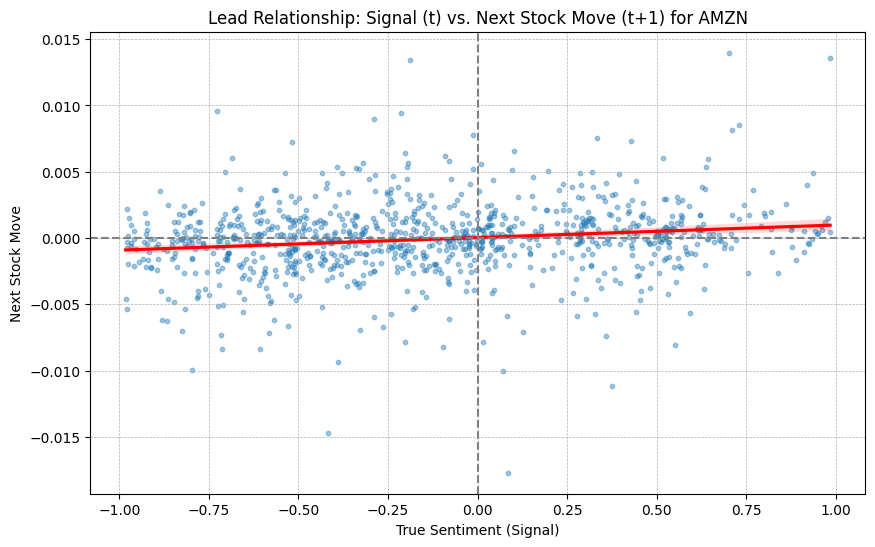

In [ ]:
#from here onwards gpt graphs
import seaborn as sns
import matplotlib.pyplot as plt

def plot_signal_vs_move(df, asset='TSLA'):
    # Filter for valid trading hours and the specific asset
    sub = df[(df['KEY'] == asset) & (df['time_to_exp'] > 2)].copy()

    # Clean data (handle infinite values if any)
    sub = sub.replace([np.inf, -np.inf], np.nan).dropna(subset=['true_sentiment', 'next_stock_move'])

    plt.figure(figsize=(10, 6))
    sns.regplot(
        x='true_sentiment',
        y='next_stock_move',
        data=sub,
        scatter_kws={'alpha': 0.4, 's': 10}, # Adjust alpha/size for density
        line_kws={'color': 'red'})
    plt.axhline(0, color='grey', linestyle='--')
    plt.axvline(0, color='grey', linestyle='--')
    plt.title(f'Lead Relationship: Signal (t) vs. Next Stock Move (t+1) for {asset}')
    plt.xlabel('True Sentiment (Signal)')
    plt.ylabel('Next Stock Move')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

# Example usage:
plot_signal_vs_move(df_15m, asset='AMZN')

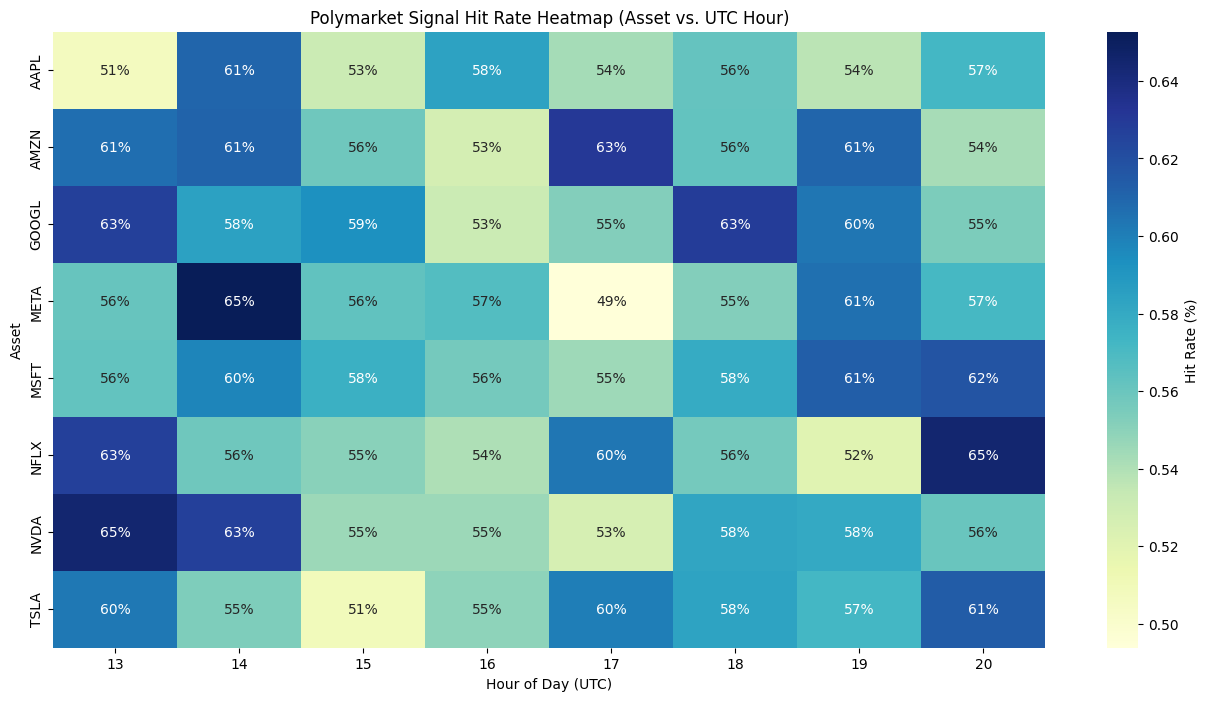

In [ ]:
def plot_hit_rate_heatmap(df):
    # Prepare data: calculate hit rate by asset and hour
    df['hour_utc'] = pd.to_datetime(df['TIMESTAMP']).dt.hour

    # We only care about signals with some conviction
    df = df[df['abs_sentiment'] > 0.05].copy()
    df['is_hit'] = (np.sign(df['true_sentiment']) == np.sign(df['next_stock_move'])).astype(int)

    heatmap_data = df.groupby(['KEY', 'hour_utc'])['is_hit'].mean().unstack()

    plt.figure(figsize=(16, 8))
    sns.heatmap(
        heatmap_data,
        cmap='YlGnBu', # Yellow -> Green -> Blue (bright green = high hit rate)
        annot=True,     # Show values
        fmt=".0%",      # Format as percentage
        cbar_kws={'label': 'Hit Rate (%)'}
    )
    plt.title('Polymarket Signal Hit Rate Heatmap (Asset vs. UTC Hour)')
    plt.xlabel('Hour of Day (UTC)')
    plt.ylabel('Asset')
    plt.show()

# Example usage:
plot_hit_rate_heatmap(df_15m)